In [25]:
# -*- coding: utf-8 -*-
# Naver DataLab 검색량 × 매출 상관분석 (키워드 세트 언제든 교체 가능)
# pip install requests pandas matplotlib

import json, requests
import pandas as pd
from pathlib import Path
from datetime import datetime
import matplotlib.pyplot as plt

plt.rcParams['font.family'] ='Malgun Gothic'
plt.rcParams['axes.unicode_minus'] =False

# =========================
# 1) 설정 (이 부분만 바꿔서 여러 제품 비교)
# =========================
CLIENT_ID = "tKt0dxpH7FcHzVbvO6Go"
CLIENT_SECRET = "OCXPe7skCG"

# 매출 엑셀: 행=구분(총매출/동원에프앤비 등), 열="YYYY년 MM월" 형태
# SALES_XLSX = "매출 데이터/캔햄 총매출.xlsx"   # 파일명/경로만 바꿔서 재사용
# SALES_XLSX = "매출 데이터/참치캔 총매출.xlsx"   # 파일명/경로만 바꿔서 재사용
SALES_XLSX = "매출 데이터/참치액 총매출.xlsx"   # 파일명/경로만 바꿔서 재사용
# ROW_NAME   = "캔햄"        # 사용할 구분(행) 이름 (예: 총매출, 동원에프앤비 등)
# ROW_NAME   = "동원에프앤비"
ROW_NAME   = "총매출"

# 분석 기간 (매출 데이터와 교집합으로 자동 맞춰짐. 여기선 상한/하한 가이드)
START = "2021-01-01"
END   = "2023-12-31"

# 원하는 키워드 세트(=주제) 구성: 자유롭게 교체/추가 가능
# 예) 다른 제품 비교하려면 아래 dict만 바꾸면 됨
# # 리챔 관련 키워드 세트
# KEYWORDS_CONFIG = {
#     "리챔": [
#         "리챔",
#         "동원리챔",
#         "리챔더블라이트",
#         "리챔오믈레햄",
#         "리챔전자레인지",
#         "리챔핫치폴레",
#         "리챔120g",
#         "리챔200g",
#         "리챔340g",
#     ]
# }
# KEYWORDS_CONFIG = {
#     "동원참치캔":   ["동원참치", "동원참치 135", "동원참치100G", "동원참치135G", "동원참치90G", "동원참치150G", "동원참치85G",
#                 "동원참치캔", "동원참치캔 100G", "동원참치캔 135G", "동원참치캔 90G", "동원참치캔 150G", "동원참치캔 85G"]
# }
KEYWORDS_CONFIG = {
    "동원 참치액": [
        "동원참치액",
        "동원참치액500","동원 참치액 500","동원 참치액500",
        "동원참치액900","동원 참치액 900","동원 참치액900","동원참치액900g","동원 참치액 900g",
        "동원참치액진","동원 참치액 진",
        "동원참치액진900","동원 참치액 진 900",
        "동원참치액 진 순","동원참치액 순","동원 참치액 순",
#        "동원참치","동원 참치",
        "동원참치액진순맛차이","동원참치액진순비교","동원참치액900g진순차이"
    ]
}

# 랙(개월) 자동 테스트 범위 (0이면 동시, 1이면 검색이 1개월 선행)
LAG_RANGE = range(0, 4)  # 0~3개월 테스트





In [23]:
# =========================
# 2) 유틸/함수
# =========================
def load_sales_wide_to_long(xlsx_path: str, row_name: str) -> pd.DataFrame:
    """와이드(열=월) 엑셀을 롱(date, 매출)으로 변환하고 대상 행(row_name)만 반환."""
    df = pd.read_excel(xlsx_path, sheet_name=0)
    if "구분" not in df.columns:
        raise ValueError("엑셀에 '구분' 컬럼이 필요합니다.")

    df_long = df.melt(id_vars=["구분"], var_name="date", value_name="매출")
    df_long["date"] = pd.to_datetime(df_long["date"], format="%Y년 %m월")
    out = (
        df_long[df_long["구분"] == row_name]
        .drop(columns="구분")
        .sort_values("date")
        .reset_index(drop=True)
    )
    return out  # columns: date, 매출


def fetch_datalab_monthly(client_id: str, client_secret: str,
                          groups: dict, start: str, end: str,
                          save_csv: str = None) -> pd.DataFrame:
    """DataLab 검색량(월) 수집. groups={'주제명':[키워드,...], ...}
       save_csv 경로를 지정하면 CSV로 저장."""
    url = "https://openapi.naver.com/v1/datalab/search"
    headers = {
        "X-Naver-Client-Id": client_id,
        "X-Naver-Client-Secret": client_secret,
        "Content-Type": "application/json",
    }
    body = {
        "startDate": start,
        "endDate": end,
        "timeUnit": "month",
        "keywordGroups": [
            {"groupName": name, "keywords": kwds}
            for name, kwds in groups.items()
        ],
    }
    r = requests.post(url, headers=headers, data=json.dumps(body))
    r.raise_for_status()
    data = r.json()

    out = None
    for res in data["results"]:
        title = res["title"]  # groupName
        dfi = pd.DataFrame(res["data"])  # period, ratio
        dfi.rename(columns={"period": "date", "ratio": title}, inplace=True)
        if out is None:
            out = dfi
        else:
            out = out.merge(dfi, on="date", how="outer")
    out["date"] = pd.to_datetime(out["date"])
    out = out.sort_values("date").reset_index(drop=True)

    # ✅ CSV 저장
    if save_csv:
        Path(save_csv).parent.mkdir(parents=True, exist_ok=True)
        out.to_csv(save_csv, index=False, encoding="utf-8-sig")
        print(f"[Saved] DataLab 검색량 → {save_csv}")

    return out


def merge_sales_search(df_sales: pd.DataFrame, df_search: pd.DataFrame,
                       save_csv: str = None) -> pd.DataFrame:
    """월 기준 내부 결합 & 결측 제거 + 선택 저장."""
    df = pd.merge(df_sales, df_search, on="date", how="inner").dropna().reset_index(drop=True)

    # ✅ CSV 저장
    if save_csv:
        Path(save_csv).parent.mkdir(parents=True, exist_ok=True)
        df.to_csv(save_csv, index=False, encoding="utf-8-sig")
        print(f"[Saved] 매출×검색량 병합 → {save_csv}")

    return df

def save_corr_reports(rep: pd.DataFrame, best: pd.DataFrame, out_dir: str, prefix: str = ""):
    Path(out_dir).mkdir(parents=True, exist_ok=True)
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    p1 = Path(out_dir) / f"{prefix}lag_corr_full_{ts}.csv"
    p2 = Path(out_dir) / f"{prefix}lag_corr_best_{ts}.csv"
    rep.to_csv(p1, index=False, encoding="utf-8-sig")
    best.to_csv(p2, index=False, encoding="utf-8-sig")
    print(f"[Saved] lag별 상관계수 전체 → {p1}")
    print(f"[Saved] 키워드별 최적 lag → {p2}")


def corr_with_lags(df: pd.DataFrame, sales_col: str, search_cols: list, lag: int = 0) -> pd.Series:
    """매출을 lag만큼 뒤로 이동시켜 상관을 계산(검색이 선행한다 가정)."""
    tmp = df.copy()
    if lag > 0:
        tmp = tmp.copy()
        tmp[sales_col] = tmp[sales_col].shift(-lag)  # 검색량이 선행 → 매출을 미래로 이동
    tmp = tmp.dropna()
    return tmp[[sales_col] + search_cols].corr(numeric_only=True)[sales_col].drop(labels=[sales_col])


def auto_corr_report(df: pd.DataFrame, sales_col="매출") -> pd.DataFrame:
    """LAG_RANGE에 대해 검색열들과의 상관을 모두 계산, 최고치/최적 lag 리포트."""
    search_cols = [c for c in df.columns if c not in ("date", sales_col)]
    rows = []
    for lag in LAG_RANGE:
        s = corr_with_lags(df, sales_col, search_cols, lag=lag)
        for k, v in s.items():
            rows.append({"keyword": k, "lag": lag, "corr": v})
    rep = pd.DataFrame(rows)
    # 키워드별 최고 상관 행만
    best = rep.sort_values(["keyword", "corr"], ascending=[True, False]).groupby("keyword").head(1).reset_index(drop=True)
    return rep, best


def quick_plot(df_merge: pd.DataFrame, search_cols: list):
    """정규화 추이 플롯(간단 비교)."""
    plt.figure(figsize=(12,5))
    norm_sales = df_merge["매출"] / df_merge["매출"].max()
    plt.plot(df_merge["date"], norm_sales, label="매출(정규화)")
    for c in search_cols:
        plt.plot(df_merge["date"], df_merge[c]/100.0, label=f"{c} 검색(0~1)")
    plt.title("매출 vs 검색량(정규화)")
    plt.xlabel("date"); plt.ylabel("normalized"); plt.xticks(rotation=45)
    plt.legend(); plt.tight_layout()
    plt.show()

[Saved] DataLab 검색량 → outputs/총매출_naver_datalab_search.csv
[Saved] 매출×검색량 병합 → outputs/총매출_merged_sales_search.csv
[Saved] lag별 상관계수 전체 → outputs\총매출lag_corr_full_20250827_123906.csv
[Saved] 키워드별 최적 lag → outputs\총매출lag_corr_best_20250827_123906.csv


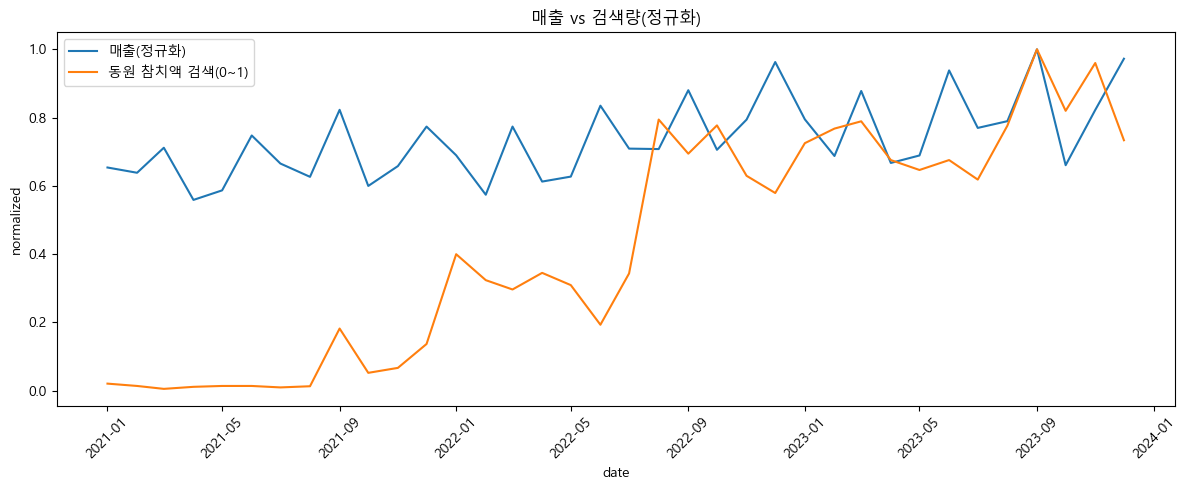

In [26]:
# 1) 매출 로드(와이드→롱)
sales = load_sales_wide_to_long(SALES_XLSX, ROW_NAME)

# 2) 데이터랩 호출 + 저장
search = fetch_datalab_monthly(
    CLIENT_ID, CLIENT_SECRET,
    KEYWORDS_CONFIG, START, END,
    save_csv=f"outputs/{ROW_NAME}_naver_datalab_search.csv"        # ✅ 저장
)

# 3) 매출×검색량 병합 + 저장
merged = merge_sales_search(
    sales, search,
    save_csv=f"outputs/{ROW_NAME}_merged_sales_search.csv"         # ✅ 저장
)

# 4) lag 상관계수 산출 + 저장
full, best = auto_corr_report(merged, sales_col="매출")
save_corr_reports(full, best, out_dir="outputs/", prefix=ROW_NAME)  # ✅ 저장

# 5) 시각화
search_cols = [c for c in merged.columns if c not in ("date", "매출")]
quick_plot(merged, search_cols)

def load_sales_wide_to_long(xlsx_path: str, row_name: str) -> pd.DataFrame:
    """와이드(열=월) 엑셀을 롱(date, 매출)으로 변환하고 대상 행(row_name)만 반환."""
    df = pd.read_excel(xlsx_path, sheet_name=0)
    if "구분" not in df.columns:
        raise ValueError("엑셀에 '구분' 컬럼이 필요합니다.")

    df_long = df.melt(id_vars=["구분"], var_name="date", value_name="매출")
    df_long["date"] = pd.to_datetime(df_long["date"], format="%Y년 %m월")
    out = (
        df_long[df_long["구분"] == row_name]
        .drop(columns="구분")
        .sort_values("date")
        .reset_index(drop=True)
    )
    return out  # columns: date, 매출

In [14]:
# 0) 현재 설정 다시 확인
print("ROW_NAME =", ROW_NAME)
print("KEYWORDS_CONFIG =", KEYWORDS_CONFIG)
print("기간:", START, "~", END)

# 1) 병합 테이블 기본 점검
print("\n[merged shape]", merged.shape)
print("[기간] 매출:", sales['date'].min().date(), "~", sales['date'].max().date(),
      "| 검색:", search['date'].min().date(), "~", search['date'].max().date(),
      "| 병합:", merged['date'].min().date(), "~", merged['date'].max().date())

# 2) 중복/결측/정렬 확인
print("\n[중복 rows]", merged.duplicated(subset=['date']).sum())
print("[결측 수]"); print(merged.isna().sum())

# 3) 핵심 열만 샘플 확인 (리챔 컬럼명은 실제 KEYWORDS_CONFIG의 주제명과 동일)
key_col = [k for k in merged.columns if k not in ("date","매출")][0]  # 첫 검색열
display(merged[['date','매출', key_col]].head(12))

# 4) 동월 상관(그래프와 동일 조건) 바로 계산
corr_same_month = merged['매출'].corr(merged[key_col])
print("\n[동월 상관(lag=0)]", key_col, ":", round(corr_same_month, 4))

# 5) lag 시각적 검증용: 매출을 1개월 뒤로 이동(검색이 선행) 후 동월상관
for L in (1,2,3):
    tmp = merged.copy()
    tmp['매출_shifted'] = tmp['매출'].shift(-L)
    print(f"[lag={L}] corr =", round(tmp[['매출_shifted', key_col]].dropna().corr().iloc[0,1], 4))


ROW_NAME = 총매출
KEYWORDS_CONFIG = {'동원참치캔': ['동원참치 135', '동원참치100G', '동원참치135G', '동원참치90G', '동원참치150G', '동원참치85G', '동원참치캔', '동원참치캔 100G', '동원참치캔 135G', '동원참치캔 90G', '동원참치캔 150G', '동원참치캔 85G']}
기간: 2022-01-01 ~ 2023-12-31

[merged shape] (24, 3)
[기간] 매출: 2020-01-01 ~ 2023-12-01 | 검색: 2022-01-01 ~ 2023-12-01 | 병합: 2022-01-01 ~ 2023-12-01

[중복 rows] 0
[결측 수]
date     0
매출       0
동원참치캔    0
dtype: int64


,date,매출,동원참치캔
0,2022-01-01,19656,75.24129
1,2022-02-01,16662,57.53971
2,2022-03-01,24810,67.69748
3,2022-04-01,18290,62.13873
4,2022-05-01,18833,65.06439
5,2022-06-01,25065,68.14589
6,2022-07-01,20339,76.24203
7,2022-08-01,22862,99.74571
8,2022-09-01,21651,80.16569
9,2022-10-01,17638,63.63437



[동월 상관(lag=0)] 동원참치캔 : 0.2909
[lag=1] corr = -0.075
[lag=2] corr = -0.2075
[lag=3] corr = -0.0156


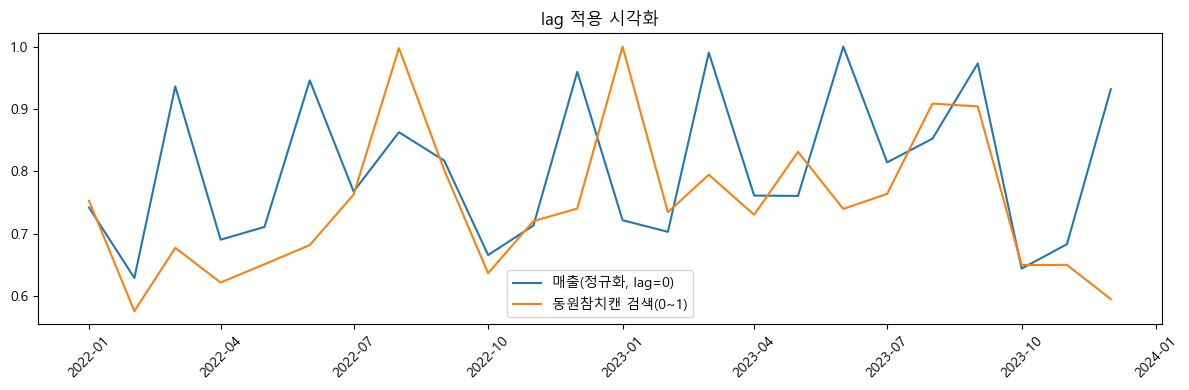

In [15]:
import matplotlib.pyplot as plt

lag = 0  # 0/1/2/3 바꿔보세요
key_col = [c for c in merged.columns if c not in ("date","매출")][0]

dfv = merged.copy()
dfv['매출_shifted'] = dfv['매출'].shift(-lag)

plt.figure(figsize=(12,4))
plt.plot(dfv['date'], dfv['매출_shifted']/dfv['매출_shifted'].max(), label=f"매출(정규화, lag={lag})")
plt.plot(dfv['date'], dfv[key_col]/100.0, label=f"{key_col} 검색(0~1)")
plt.title("lag 적용 시각화")
plt.legend(); plt.xticks(rotation=45); plt.tight_layout(); plt.show()


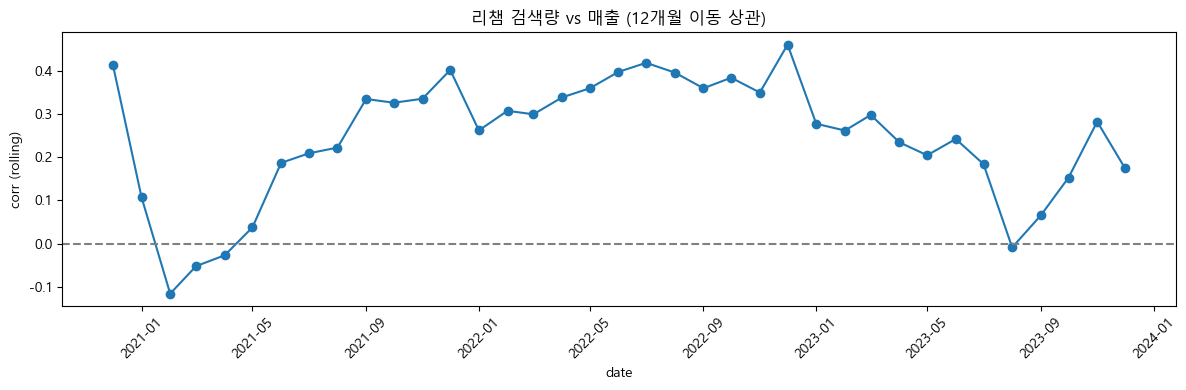

In [40]:
def rolling_corr(df, sales_col="매출", search_col="리챔", window=12):
    """
    이동 상관계수 계산 (기본: 12개월 창)
    """
    return df[sales_col].rolling(window).corr(df[search_col])

# 사용 예시
merged["rolling_corr"] = rolling_corr(merged, sales_col="매출", search_col="리챔", window=12)

plt.figure(figsize=(12,4))
plt.plot(merged["date"], merged["rolling_corr"], marker="o")
plt.axhline(0, color="gray", linestyle="--")
plt.title("리챔 검색량 vs 매출 (12개월 이동 상관)")
plt.ylabel("corr (rolling)")
plt.xlabel("date")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()